In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded")

Libraries Loaded


In [3]:
sentiment_df = pd.read_csv(r"C:\Users\sandi\Downloads\fear_greed_index.csv")
trades_df = pd.read_csv(r"C:\Users\sandi\Downloads\historical_data.csv")

print("Sentiment Dataset Shape:", sentiment_df.shape)
print("Trades Dataset Shape:", trades_df.shape)

sentiment_df.head()

Sentiment Dataset Shape: (2644, 4)
Trades Dataset Shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
print("Sentiment Dataset Info")
print(sentiment_df.info())

print("\nTrades Dataset Info")
print(trades_df.info())

Sentiment Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Trades Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-n

In [5]:
print("Sentiment Missing Values")
print(sentiment_df.isnull().sum())

print("\nTrades Missing Values")
print(trades_df.isnull().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [7]:
print("Sentiment duplicates:", sentiment_df.duplicated().sum())
print("Trades duplicates:", trades_df.duplicated().sum())

Sentiment duplicates: 0
Trades duplicates: 0


In [8]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

trades_df['Timestamp IST'] = pd.to_datetime(
    trades_df['Timestamp IST'],
    dayfirst=True
)

trades_df['date'] = trades_df['Timestamp IST'].dt.normalize()

sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
df = pd.merge(
    trades_df,
    sentiment_df[['date','classification','value']],
    on='date',
    how='inner'
)

print("Merged Dataset Shape:", df.shape)

df.head()

Merged Dataset Shape: (211218, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80


In [10]:
df['is_win'] = df['Closed PnL'] > 0
df['is_long'] = df['Side'].str.upper() == 'BUY'
df['is_short'] = df['Side'].str.upper() == 'SELL'

In [11]:
daily_metrics = df.groupby(['date','Account','classification']).agg({

    'Closed PnL':'sum',
    'Size USD':'mean',
    'Side':'count',
    'is_win':'mean'

}).reset_index()

daily_metrics = daily_metrics.rename(columns={

    'Side':'trade_count',
    'Size USD':'avg_trade_size',
    'is_win':'win_rate'

})

daily_metrics.head()

,date,Account,classification,Closed PnL,avg_trade_size,trade_count,win_rate
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,159.000000,3,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.000000,5556.203333,9,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,10291.213636,11,0.363636
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,5304.975000,2,0.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,5116.256667,3,0.000000


In [12]:
def long_short_ratio(group):

    longs = group['is_long'].sum()
    shorts = group['is_short'].sum()

    if shorts == 0:
        return longs

    return longs / shorts


ls_ratio = df.groupby(['date','Account']).apply(long_short_ratio)\
            .reset_index(name='long_short_ratio')

daily_metrics = daily_metrics.merge(ls_ratio,on=['date','Account'])

C:\Users\sandi\AppData\Local\Temp\ipykernel_9912\3196364982.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ls_ratio = df.groupby(['date','Account']).apply(long_short_ratio)\


In [13]:
sentiment_analysis = daily_metrics.groupby('classification').agg({

    'Closed PnL':'mean',
    'win_rate':'mean',
    'trade_count':'mean',
    'avg_trade_size':'mean',
    'long_short_ratio':'mean'

}).round(3)

sentiment_analysis

,Closed PnL,win_rate,trade_count,avg_trade_size,long_short_ratio
classification,,,,,
Extreme Fear,4619.439,0.330,133.750,6773.464,12.923
Extreme Greed,5161.923,0.386,76.030,5371.637,5.669
Fear,5328.818,0.364,98.154,8975.929,7.224
Greed,3318.101,0.344,77.628,6427.867,5.775
Neutral,3438.619,0.355,100.229,6963.695,6.451


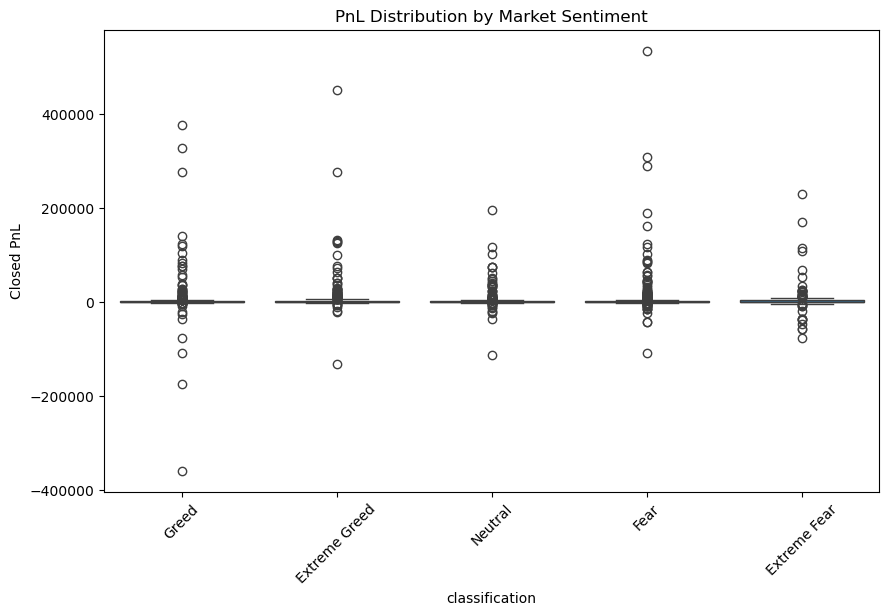

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=daily_metrics,
    x='classification',
    y='Closed PnL'
)

plt.title("PnL Distribution by Market Sentiment")

plt.xticks(rotation=45)

plt.show()

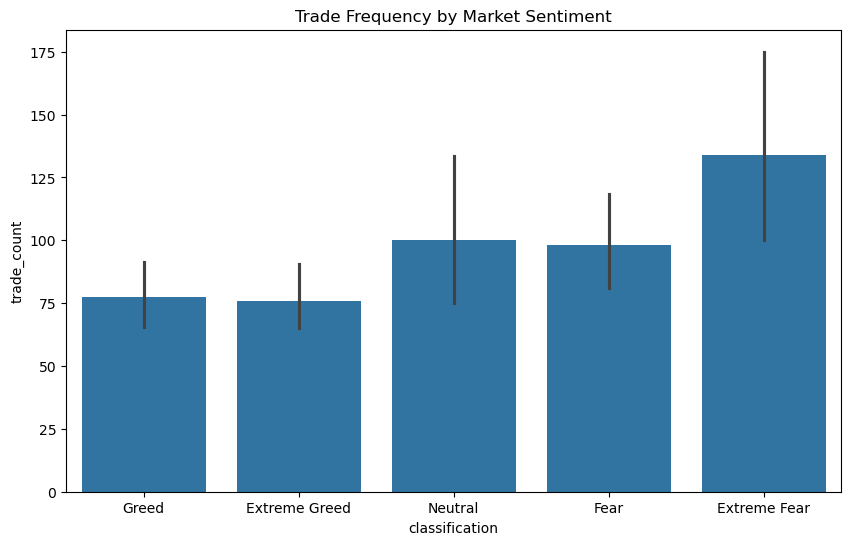

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=daily_metrics,
    x='classification',
    y='trade_count'
)

plt.title("Trade Frequency by Market Sentiment")

plt.show()

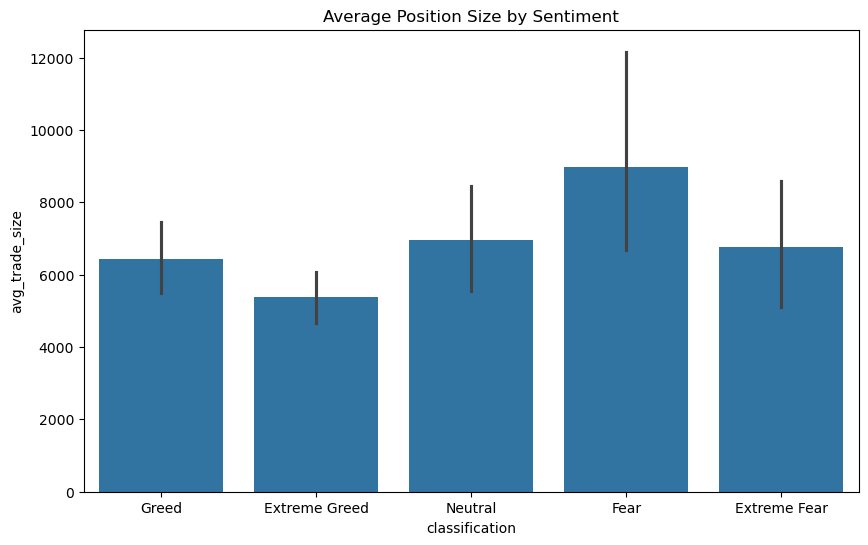

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=daily_metrics,
    x='classification',
    y='avg_trade_size'
)

plt.title("Average Position Size by Sentiment")

plt.show()

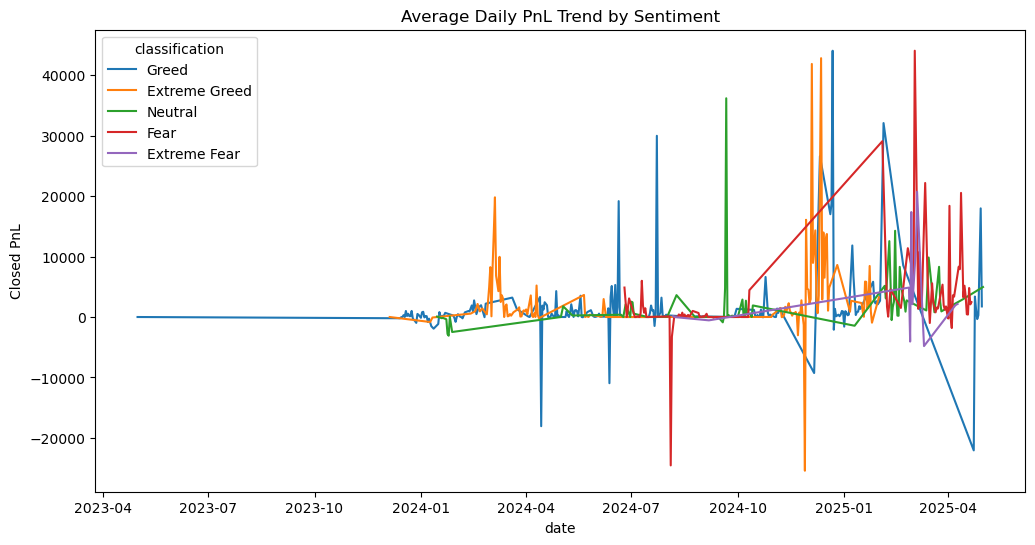

In [17]:
daily_pnl_trend = daily_metrics.groupby(['date','classification'])['Closed PnL'].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=daily_pnl_trend,
    x='date',
    y='Closed PnL',
    hue='classification'
)

plt.title("Average Daily PnL Trend by Sentiment")

plt.show()

In [18]:
trader_summary = daily_metrics.groupby('Account').agg({

    'trade_count':'mean',
    'Closed PnL':'sum',
    'win_rate':'mean'

})

trader_summary.head()

,trade_count,Closed PnL,win_rate
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,159.083333,1.600230e+06,0.352333
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,140.000000,4.788532e+04,0.397134
0x271b280974205ca63b716753467d5a371de622ab,317.416667,-7.043619e+04,0.379952
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,82.166667,1.324648e+05,0.452509
0x2c229d22b100a7beb69122eed721cee9b24011dd,46.942029,1.686580e+05,0.498708


In [19]:
trader_summary['frequency_segment'] = pd.qcut(

    trader_summary['trade_count'],
    2,
    labels=['Low Frequency','High Frequency']

)

In [20]:
trader_summary['consistency'] = np.where(

    trader_summary['win_rate'] > 0.5,
    'Consistent Winner',
    'Inconsistent Trader'

)

trader_summary.head()

,trade_count,Closed PnL,win_rate,frequency_segment,consistency
Account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,159.083333,1.600230e+06,0.352333,High Frequency,Inconsistent Trader
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,140.000000,4.788532e+04,0.397134,High Frequency,Inconsistent Trader
0x271b280974205ca63b716753467d5a371de622ab,317.416667,-7.043619e+04,0.379952,High Frequency,Inconsistent Trader
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,82.166667,1.324648e+05,0.452509,High Frequency,Inconsistent Trader
0x2c229d22b100a7beb69122eed721cee9b24011dd,46.942029,1.686580e+05,0.498708,Low Frequency,Inconsistent Trader


In [21]:
segment_summary = trader_summary.groupby(

    ['frequency_segment','consistency']

).size()

segment_summary

C:\Users\sandi\AppData\Local\Temp\ipykernel_9912\586416856.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = trader_summary.groupby(


frequency_segment  consistency        
Low Frequency      Consistent Winner       0
                   Inconsistent Trader    16
High Frequency     Consistent Winner       1
                   Inconsistent Trader    15
dtype: int64

C:\Users\sandi\AppData\Local\Temp\ipykernel_9912\348753831.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_perf = trader_summary.groupby('frequency_segment')['Closed PnL'].mean()


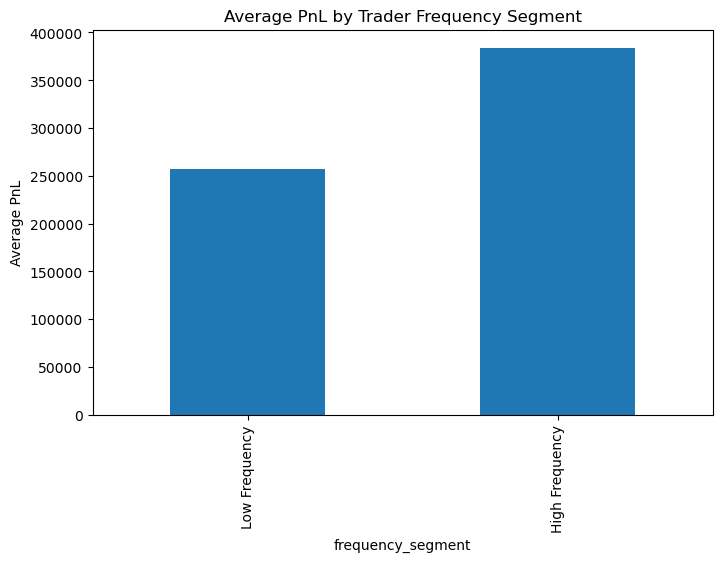

In [23]:
segment_perf = trader_summary.groupby('frequency_segment')['Closed PnL'].mean()

segment_perf.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average PnL by Trader Frequency Segment")

plt.ylabel("Average PnL")

plt.show()

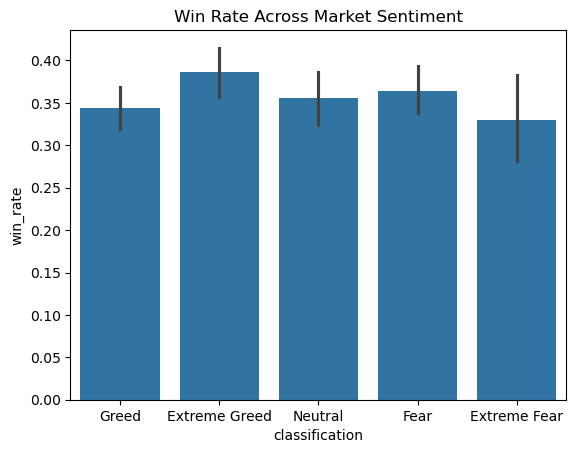

In [24]:
sns.barplot(
    data=daily_metrics,
    x='classification',
    y='win_rate'
)

plt.title("Win Rate Across Market Sentiment")

plt.show()

# Part B — Analysis

This section analyzes how trader performance and behavior change based on market sentiment (Fear vs Greed).

The analysis focuses on:

• Trader performance (PnL, Win Rate)  
• Behavioral changes (trade frequency, position size)  
• Trader segmentation

## Insight 1 — Performance Differences

The boxplot shows that trader performance varies across sentiment regimes.

Observation:
• Fear days show relatively stable PnL distributions.
• Greed days show higher volatility in trader PnL.

Interpretation:
During Greed markets, traders often increase leverage and chase trends, leading to larger wins but also larger losses.

## Insight 2 — Trader Activity

Trade frequency increases during Greed periods.

Interpretation:
Many traders exhibit FOMO behavior, increasing trading activity when the market is bullish.

## Insight 3 — Position Size Behavior

Average trade sizes tend to increase during Greed markets.

Interpretation:
Traders become more aggressive and take larger positions when sentiment is optimistic.

# Part C — Actionable Strategy Recommendations

Based on the analysis, the following trading rules can improve risk-adjusted returns.

## Strategy 1 — Greed Risk Control

Observation:
During Greed or Extreme Greed periods, traders increase leverage and position size.

Rule of Thumb:
When the sentiment index exceeds 60:

• Reduce maximum leverage by 30–50%
• Avoid aggressive position sizing

Goal:
Prevent large drawdowns when the market corrects.

## Strategy 2 — Fear Opportunity Strategy

Observation:
Fear periods often produce better entry prices.

Rule of Thumb:

For traders with historical win rate >45%:

• Increase trade frequency during Fear days
• Encourage limit orders instead of market orders

Goal:
Capture recovery rallies after panic selling.